In [362]:
import scipy as sp
from scipy.special import jv, hankel2, yv, spherical_jn, spherical_yn
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones, argmin, log, unravel_index, pi, array
from utils import e_r_cpa_numerator, e_r_cpa, hl2, hl2prime, hl1, hl1prime
from refractiveindex import RefractiveIndexMaterial

## We first compare the Drude parameters of the paper with the experimental values obtained from Johnson and Christy. It seems the paper is primarily interested in the region $0<\omega<\omega_p$, so this is the region we look at 

In [363]:
omega_p = 7.9 # Bulk plasma frequency in eV
gamma_e = 0.09 # Drude electronic relaxation time in eV
hbar_c = 6.58211957 * 3 * 10 #200 # in nanometers * eV
lambda_min = 2*pi/(omega_p/hbar_c) * 1.2 # We'd like to go down to the plasma frequency but Johnson & Christy doesn't have data in that frequency range
lambda_max = 10 * lambda_min
Gold = RefractiveIndexMaterial(shelf='main', book='Au', page='Johnson')
#Gold = RefractiveIndexMaterial(shelf='main', book='Au', page='Werner-DFT')

wavelengths_nm = linspace(lambda_min, lambda_max, 301)  # [nm]
omegas_ev = hbar_c * (2*pi/wavelengths_nm)
gold_epsilon = Gold.get_epsilon(wavelengths_nm)
gold_epsilon_drude = 1 - omega_p**2/(omegas_ev*(omegas_ev + 1j*gamma_e))

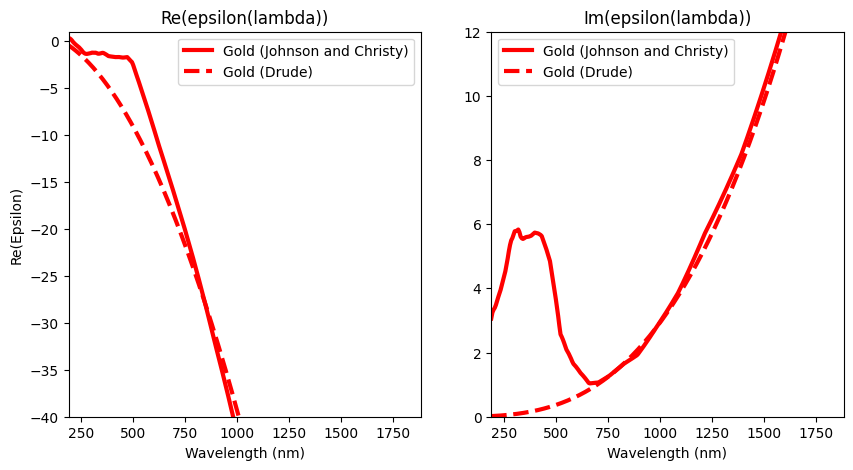

In [364]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.plot(wavelengths_nm, gold_epsilon.real, color="red", label="Gold (Johnson and Christy)", linewidth=3)
ax1.plot(wavelengths_nm, gold_epsilon_drude.real, color="red", label="Gold (Drude)", linestyle="dashed", linewidth=3)

ax2.plot(wavelengths_nm, gold_epsilon.imag, color="red", label="Gold (Johnson and Christy)", linewidth=3)
ax2.plot(wavelengths_nm, gold_epsilon_drude.imag, color="red", label="Gold (Drude)", linestyle="dashed", linewidth=3)

ax1.set_xlim(lambda_min, lambda_max);
ax2.set_xlim(lambda_min, lambda_max);
ax1.set_title("Re(epsilon(lambda))")
ax2.set_title("Im(epsilon(lambda))")
ax1.legend();
ax2.legend();
ax1.set_xlabel("Wavelength (nm)")
ax2.set_xlabel("Wavelength (nm)")
ax1.set_ylabel("Re(Epsilon)");
ax1.set_ylim(-40, 1)
ax2.set_ylim(0, 12);

In [365]:
def recursive_cpa(previous_coefficients, l, epsilon1, epsilon2, kR):

    x = sqrt(epsilon2) * kR
    y = sqrt(epsilon1) * kR
    
    mat1_11 = hl1(l, y)
    mat1_12 = hl2(l, y)
    
    yhl1_prime = hl1(l, y) + y * hl1prime(l, y)
    yhl2_prime = hl2(l, y) + y * hl2prime(l, y)
    
    mat1_21 = epsilon2 * yhl1_prime
    mat1_22 = epsilon2 * yhl2_prime
    
    xhl1_prime = hl1(l, x) + x * hl1prime(l, x)
    xhl2_prime = hl2(l, x) + x * hl2prime(l, x)
    
    mat2_11 = epsilon1 * xhl2_prime
    mat2_12 = -hl2(l, x)
    
    mat2_21 = -epsilon1 * xhl1_prime
    mat2_22 = hl1(l, x)
    
    
    mat1 = np.array([[mat1_11, mat1_12], [mat1_21, mat1_22]])
    mat2 = np.array([[mat2_11, mat2_12], [mat2_21, mat2_22]])
    
    next_coefficients = np.einsum("ij..., jk..., k...->i...", mat2, mat1, previous_coefficients)

    return next_coefficients


In [366]:
# We define the drude dielectric function, which takes in the ratio omega/omega_p
def gold_drude(omega_over_omega_p, omega_p=7.9, gamma_e=0.09):
    return 1-1/(omega_over_omega_p*(omega_over_omega_p+1j*gamma_e/omega_p))

In [429]:
K = 100
N = 200
l = 1
H = 1.2 
Rs = linspace(2, 7, K)
omega_over_omega_ps_real = linspace(0.01, 1, N) # range of real(omega)/omega_p
omega_over_omega_ps_imag = linspace(0.0001, 1, N) # range of imag(omega)/omega_p
omega_over_omega_ps = omega_over_omega_ps_real.reshape((N, 1)).repeat(N, axis=1) - 1j*omega_over_omega_ps_imag.reshape((1, N)).repeat(N, axis=0)
gammas = np.zeros((K, N))
gamma_e = 0

heatmap_data = np.zeros((K, N))
for (R_idx, R) in enumerate(Rs):
    if (R_idx % 10) == 0:
        print(R_idx)
    epsilon2 = gold_drude(omega_over_omega_ps, gamma_e=gamma_e); epsilon1 =  ones((N, N))
    kR = R * omega_over_omega_ps
    previous_coefficients = np.array([1, 1])
    
    next_coefficients = recursive_cpa(previous_coefficients, l, epsilon1, epsilon2, kR)
    
    epsilon2 = ones((N, N)) ; epsilon1 = gold_drude(omega_over_omega_ps, gamma_e=gamma_e); 
    kR =  (H+R) * omega_over_omega_ps
    next_coefficients = recursive_cpa(next_coefficients, l, epsilon1, epsilon2, kR)
    
    scattering_amplitudes = np.abs(next_coefficients[0, ...]/next_coefficients[1, ...])**2
    heatmap_data[R_idx, :] =  scattering_amplitudes.max(axis=1) # maximum across all imaginary values for the frequency
    gammas[R_idx, :] = omega_over_omega_ps_imag[scattering_amplitudes.argmax(axis=1)]

0
10
20
30
40
50
60
70
80
90


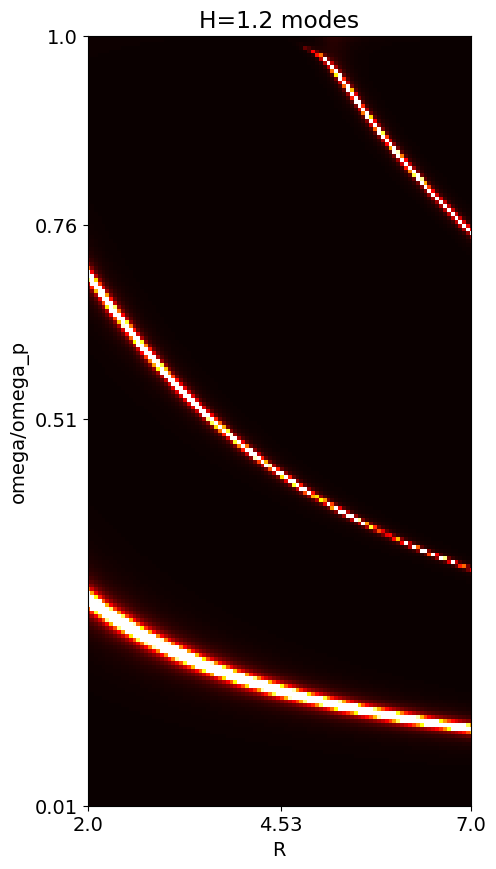

In [457]:
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(10,10))
ax.imshow(heatmap_data.T, cmap="hot", vmin=1, vmax=200, origin="lower");
ax.set_xticks([0, K/2, K-1], Rs[[0, round(K/2), K-1]].round(2))
ax.set_yticks([0, N/2, N*3/4, N-1], omega_over_omega_ps_real[[0, round(N/2), round(3*N/4), N-1]].round(2))
ax.set_xlim(0, K-1)
ax.set_ylim(0, N-1);
ax.set_xlabel("R")
ax.set_ylabel("omega/omega_p");
ax.set_title("H=1.2 modes");

In [458]:
x, y = np.where(heatmap_data > 20) # Find where the modes are 
first_mode_idxs = np.where(omega_over_omega_ps_real[y] < 0.3) # Indices for the lowest mode
x = x[first_mode_idxs]
y = y[first_mode_idxs]
filter_idxs = np.array([np.where(x==i)[0][0] for i in range(0, 100)])
x = x[filter_idxs]
y = y[filter_idxs]

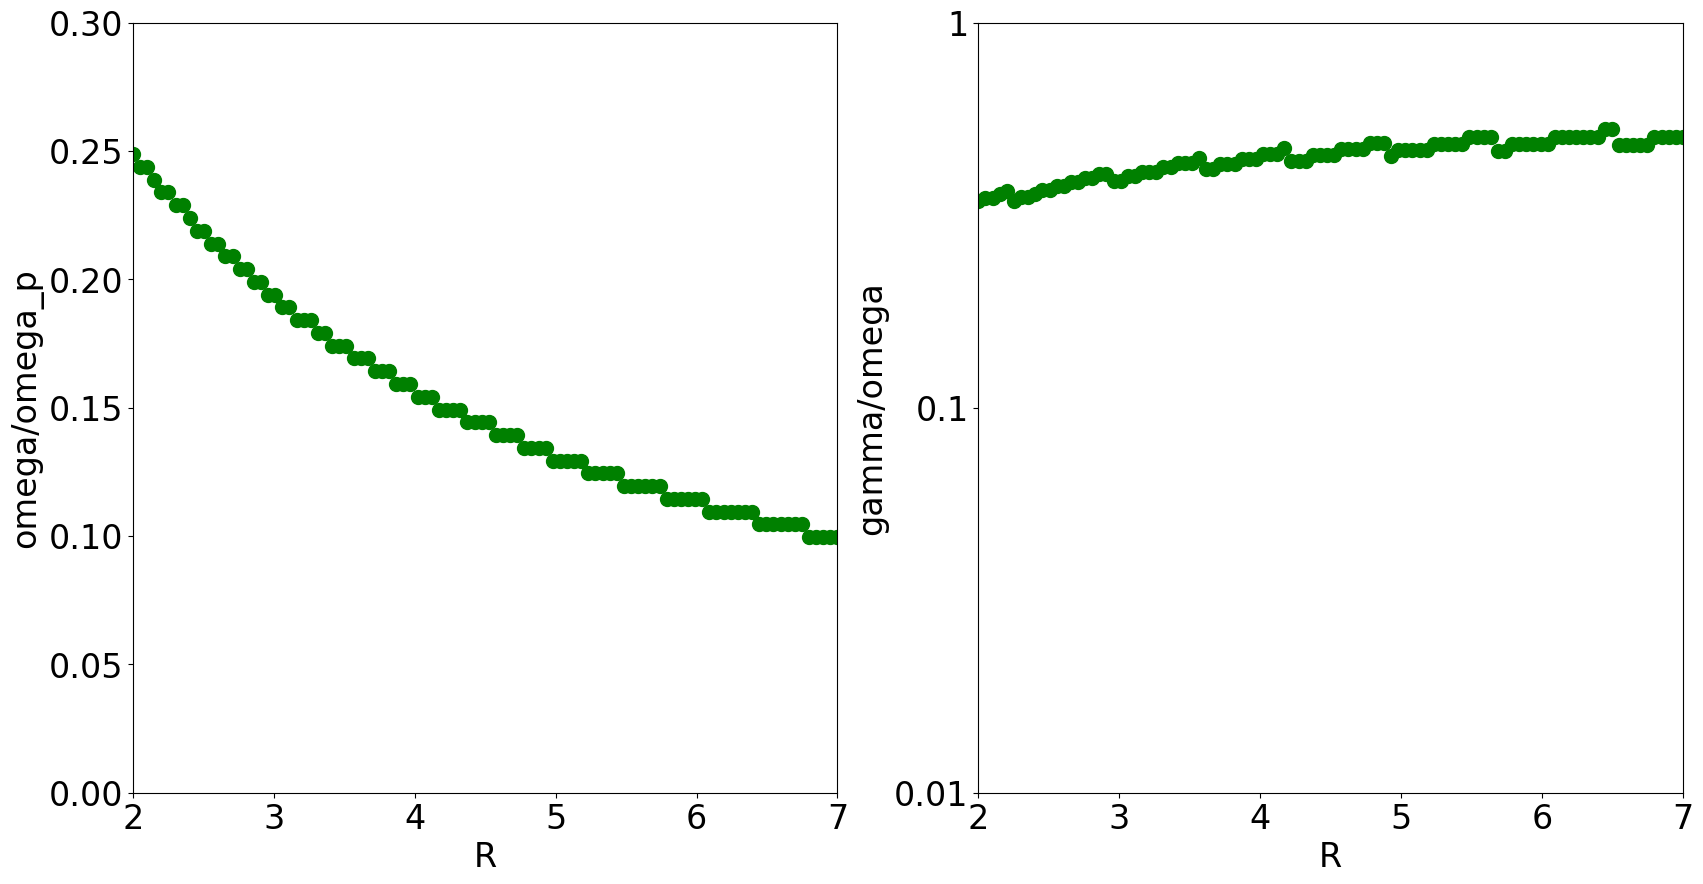

In [459]:
plt.rcParams.update({'font.size': 24})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
ax1.scatter(Rs[x], omega_over_omega_ps_real[y], color="green", s=100);
ax1.set_xlabel("R")
ax1.set_ylabel("omega/omega_p");
ax1.set_xlim(2, 7);
ax1.set_ylim(0, 0.3);

ax2.scatter(Rs[x], log(gammas[x, y]/omega_over_omega_ps_real[y]), color="green", s=100);
ax2.set_xlabel("R")
ax2.set_yticks([log(0.01), log(0.1), log(1)], [0.01, 0.1, 1])
ax2.set_ylabel("gamma/omega");
ax2.set_xlim(2, 7);
ax2.set_ylim(log(0.01), log(1));

## To make a smooth plot, we zoom in on the real and imaginary frequency ranges near the modes

In [444]:
K = 100
N = 250
gamma_e = 0
optimized_gammas = np.zeros(Rs[x].shape[0])
optimized_omegas = np.zeros(Rs[x].shape[0])
optimized_Rs = np.zeros(Rs[x].shape[0])
for idx in range(0, Rs[x].shape[0]):
    if (idx % 10) == 0: 
        print(idx)
    R = Rs[x[idx]]
    starting_omega = omega_over_omega_ps_real[y[idx]]
    starting_gamma = gammas[x[idx], y[idx]]

    omega_over_omega_ps_real_zoom = linspace(0.8, 1.2, N) * starting_omega 
    omega_over_omega_ps_imag_zoom = linspace(0.8, 1.2, N) * starting_gamma
    omega_over_omega_ps = omega_over_omega_ps_real_zoom.reshape((N, 1)).repeat(N, axis=1) - 1j*omega_over_omega_ps_imag_zoom.reshape((1, N)).repeat(N, axis=0)

    epsilon2 = gold_drude(omega_over_omega_ps, gamma_e=gamma_e); epsilon1 =  ones((N, N))
    kR = R * omega_over_omega_ps
    previous_coefficients = np.array([1, 1])
    
    next_coefficients = recursive_cpa(previous_coefficients, l, epsilon1, epsilon2, kR)
    
    epsilon2 = ones((N, N)) ; epsilon1 = gold_drude(omega_over_omega_ps, gamma_e=gamma_e); 
    kR =  (H+R) * omega_over_omega_ps
    next_coefficients = recursive_cpa(next_coefficients, l, epsilon1, epsilon2, kR)
    
    scattering_amplitudes = np.abs(next_coefficients[0, ...]/next_coefficients[1, ...])**2
    max_idx = scattering_amplitudes.argmax()
    row, col = unravel_index(max_idx, (N, N))
    optimized_Rs[idx] = R
    optimized_omegas[idx] = omega_over_omega_ps_real_zoom[row]
    optimized_gammas[idx] = omega_over_omega_ps_imag_zoom[col]

0
10
20
30
40
50
60
70
80
90


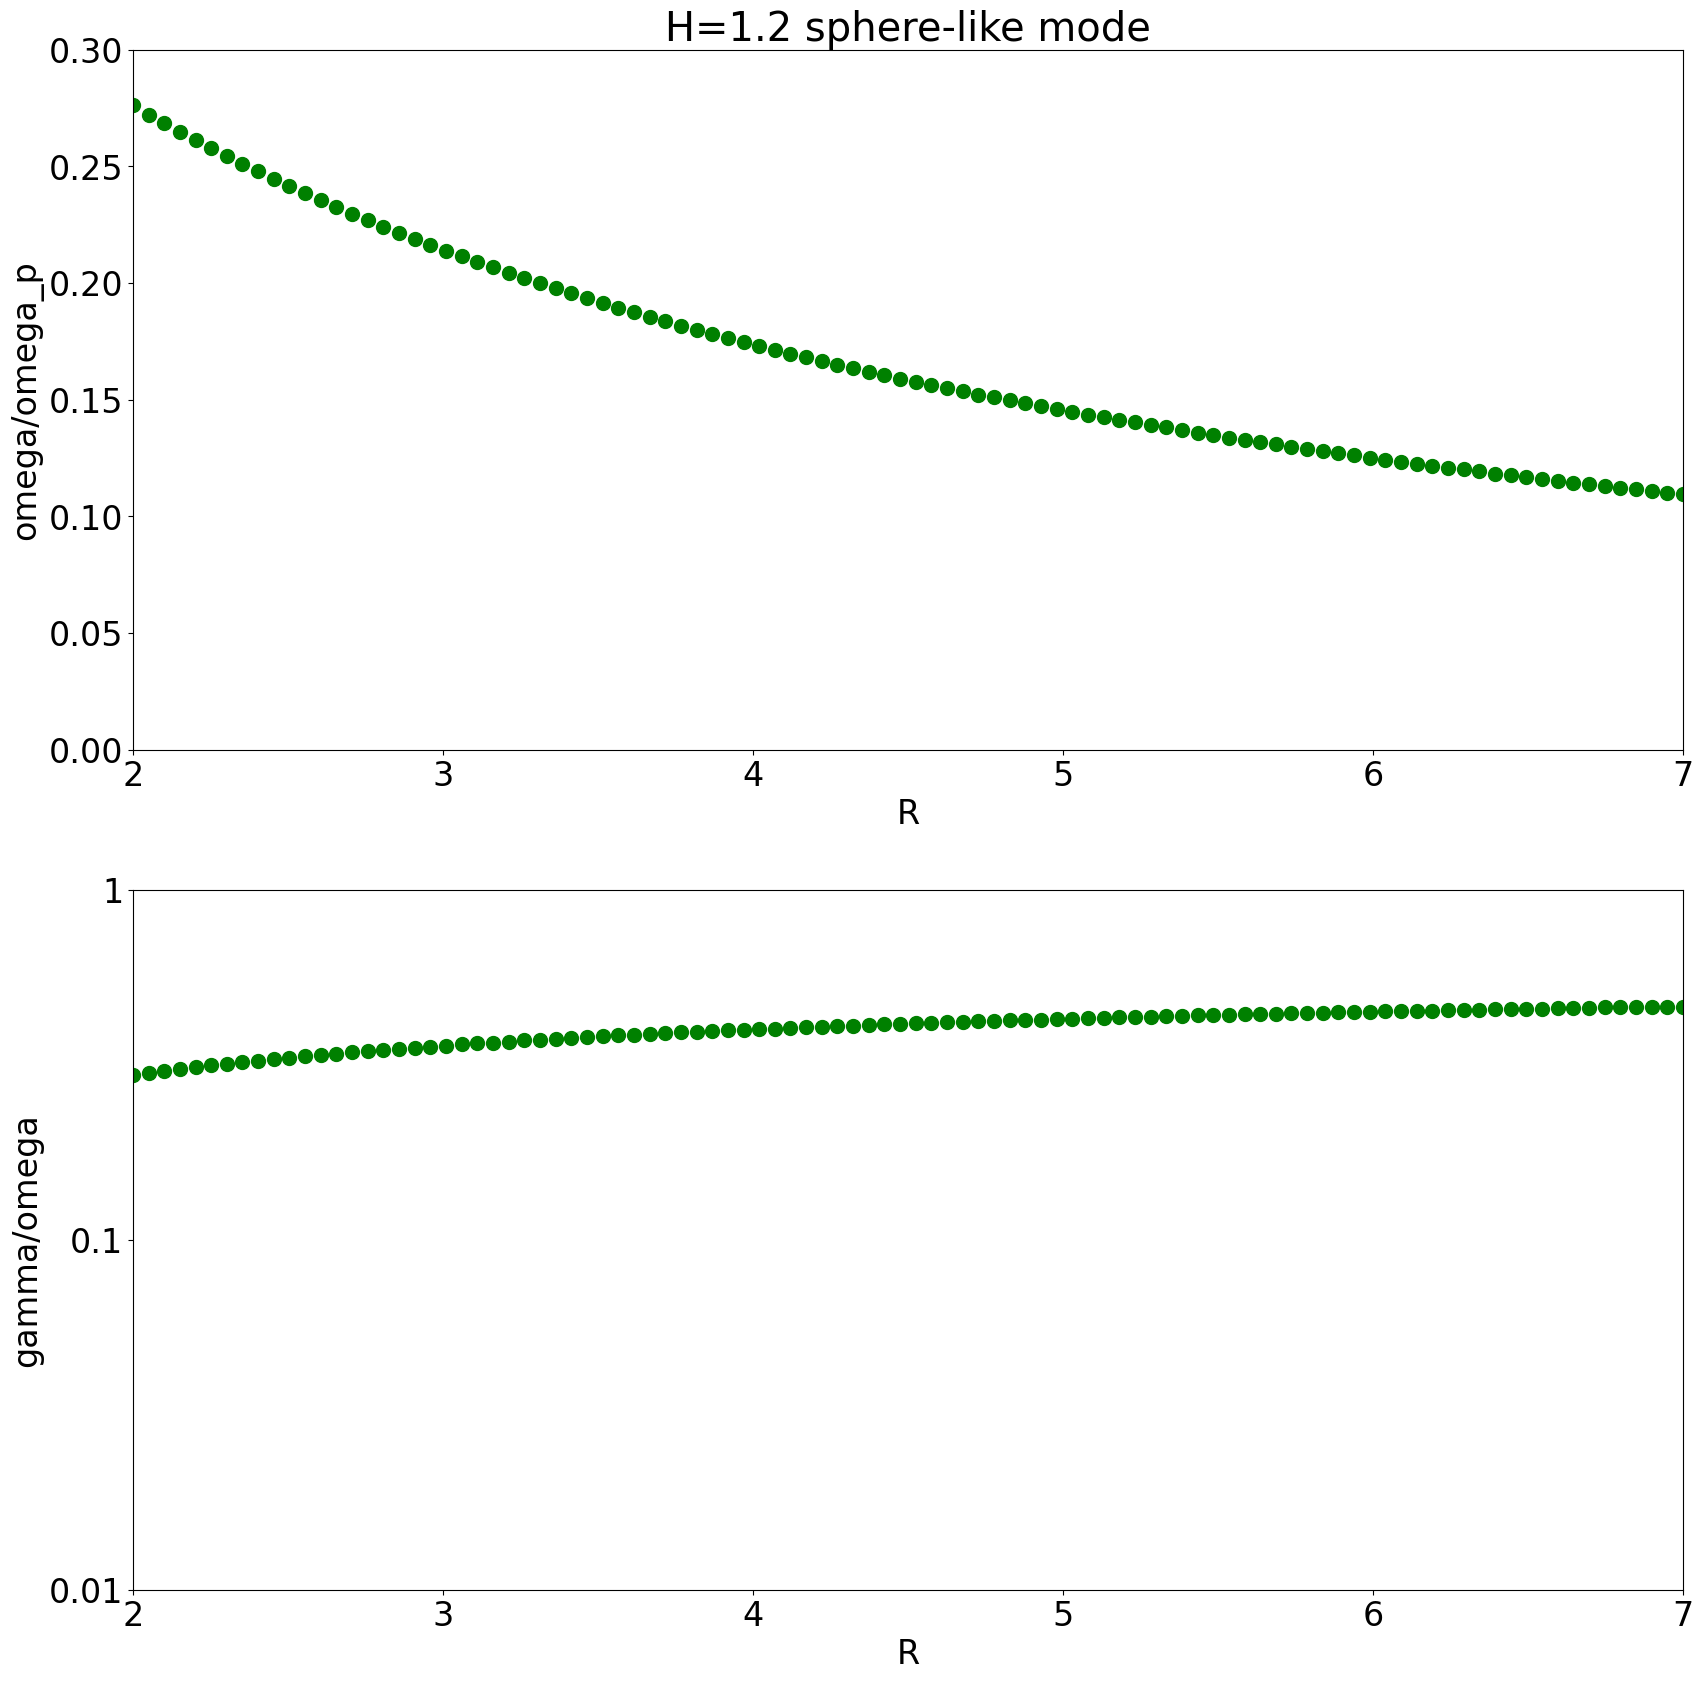

In [460]:
plt.rcParams.update({'font.size': 24})
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 20))
ax1.scatter(optimized_Rs, optimized_omegas, s=100, color="green")
ax2.scatter(optimized_Rs, log(optimized_gammas/optimized_omegas), s=100, color="green")

ax1.set_xlabel("R")
ax1.set_ylabel("omega/omega_p");
ax1.set_xlim(2, 7);
ax1.set_ylim(0, 0.3);

ax2.set_yticks([log(0.01), log(0.1), log(1)], [0.01, 0.1, 1])
ax2.set_ylabel("gamma/omega");
ax2.set_xlabel("R")
ax2.set_xlim(2, 7);
ax2.set_ylim(log(0.01), log(1));
ax1.set_title("H=1.2 sphere-like mode");